In [12]:
from phd_helpers.paramOptimisation.getInfo import get_params3d, get_runtimes, combine_metric_dfs, score_value
from phd_helpers.paths import get_info_df, get_subject_stl_path, get_mesh, avg_edge_length
from phd_helpers.MeshQuality import check_mesh_quality, mesh_quality_summary, plot_bad_cells


from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

In [13]:
# -------- PATHS --------------------------------------------- #
root_dir = Path('../../../../../MeshPipeline/outputs/initialFEAstuff/35T') # path to parent of output_root in set_parameters
study_prefix = '35T' # start of dir name of output_root in set_parameters

out_dir = Path(f'outputs') # path dir to save outputs in
suffixes = ['a', 'b', 'd', 'e', 'f', 'g'] # individual study identifier (end of dir name of output_root in set_parameters)

In [14]:
get_runtimes(root_dir, study_prefix, suffixes).to_csv(out_dir / 'runtimes.csv', index=False)
extra_params = [
    'cgal_params.optimisation.odt',
    'cgal_params.optimisation.lloyd',
    ]
get_params3d(root_dir, study_prefix, suffixes, extra_params).to_csv(out_dir / 'params.csv', index=False)

prefixes = [f'{study_prefix}{suffix}-0{suffix}' for suffix in suffixes] # only works if only need full_params.json
df_bone, df_cart, df_qual = combine_metric_dfs(out_dir, prefixes)

df_bone.to_csv(out_dir / 'df_bone.csv', index=False)
df_cart.to_csv(out_dir / 'df_cart.csv', index=False)
df_qual.to_csv(out_dir / 'df_qual.csv', index=False)

In [15]:
# LOAD DATA

df_bone = pd.read_csv(out_dir / 'df_bone.csv')
df_cart = pd.read_csv(out_dir / 'df_cart.csv')
df_qual = pd.read_csv(out_dir / 'df_qual.csv')

df_param = pd.read_csv(out_dir / 'params.csv')
df_run = pd.read_csv(out_dir / 'runtimes.csv')

In [16]:
bone = 'tpm'

d_metric2 = 'max'
d_metric1 = '99'
iteration_cart = 'remesh2d'
iteration_bone = 'remesh2d'
loc = 'i'

qual_metric = '99%'
qual_part = 'full'
qual_part2 = 'cart_inner'

metrics = [

    # fidelity (keep high)
    f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'bone_{iteration_bone}_d{loc}_{d_metric2}',
    f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'cart_{iteration_cart}_d{loc}_{d_metric2}',

    # quality (keep high)
    f'{qual_part}_min_angle_{qual_metric}',
    f'{qual_part}_scaled_jacobian_{qual_metric}',
    f'{qual_part}_aspect_ratio_{qual_metric}',
    f'{qual_part}_radius_ratio_{qual_metric}',
    f'{qual_part}_min_angle_worst',
    f'{qual_part}_scaled_jacobian_worst',
    f'{qual_part}_aspect_ratio_worst',
    f'{qual_part}_radius_ratio_worst',

]


bone_df = df_bone[
    ['sub', 'bone', 'run_id', f'{iteration_bone}_d{loc}_{d_metric1}', f'{iteration_bone}_d{loc}_{d_metric2}', 'remesh3d_vol']
].rename(columns={
    f'{iteration_bone}_d{loc}_{d_metric1}': f'bone_{iteration_bone}_d{loc}_{d_metric1}',
    f'{iteration_bone}_d{loc}_{d_metric2}': f'bone_{iteration_bone}_d{loc}_{d_metric2}'
})

cart_df = df_cart[
    ['sub', 'bone', 'run_id', f'{iteration_cart}_d{loc}_{d_metric1}', f'{iteration_cart}_d{loc}_{d_metric2}']
].rename(columns={
    f'{iteration_cart}_d{loc}_{d_metric1}': f'cart_{iteration_cart}_d{loc}_{d_metric1}',
    f'{iteration_cart}_d{loc}_{d_metric2}': f'cart_{iteration_cart}_d{loc}_{d_metric2}'
})

qual = df_qual[
    [
        'sub', 'bone', 'run_id',
        f'{qual_part}_min_angle_worst',
        f'{qual_part}_scaled_jacobian_worst',
        f'{qual_part}_aspect_ratio_worst',
        f'{qual_part}_radius_ratio_worst',
        f'{qual_part2}_min_angle_worst',
        f'{qual_part2}_scaled_jacobian_worst',
        f'{qual_part2}_aspect_ratio_worst',
        f'{qual_part2}_radius_ratio_worst',
        f'{qual_part}_min_angle_{qual_metric}',
        f'{qual_part}_scaled_jacobian_{qual_metric}',
        f'{qual_part}_aspect_ratio_{qual_metric}',
        f'{qual_part}_radius_ratio_{qual_metric}',
        'full_n_cells',
    ]
]

df = (
    bone_df
    .merge(cart_df, on=['sub', 'bone', 'run_id'], how='inner')
    .merge(qual, on=['sub', 'bone', 'run_id'], how='inner')
)
df = df[(df['bone_remesh2d_di_max']<0.1)&(df['cart_remesh2d_di_max']<0.1)&(df['full_scaled_jacobian_worst']>0.04)] # remove any where odt chipped tets

#df = df[df['bone']==bone]

print(len(df))

159


Highest element count:
	50034R - 347550


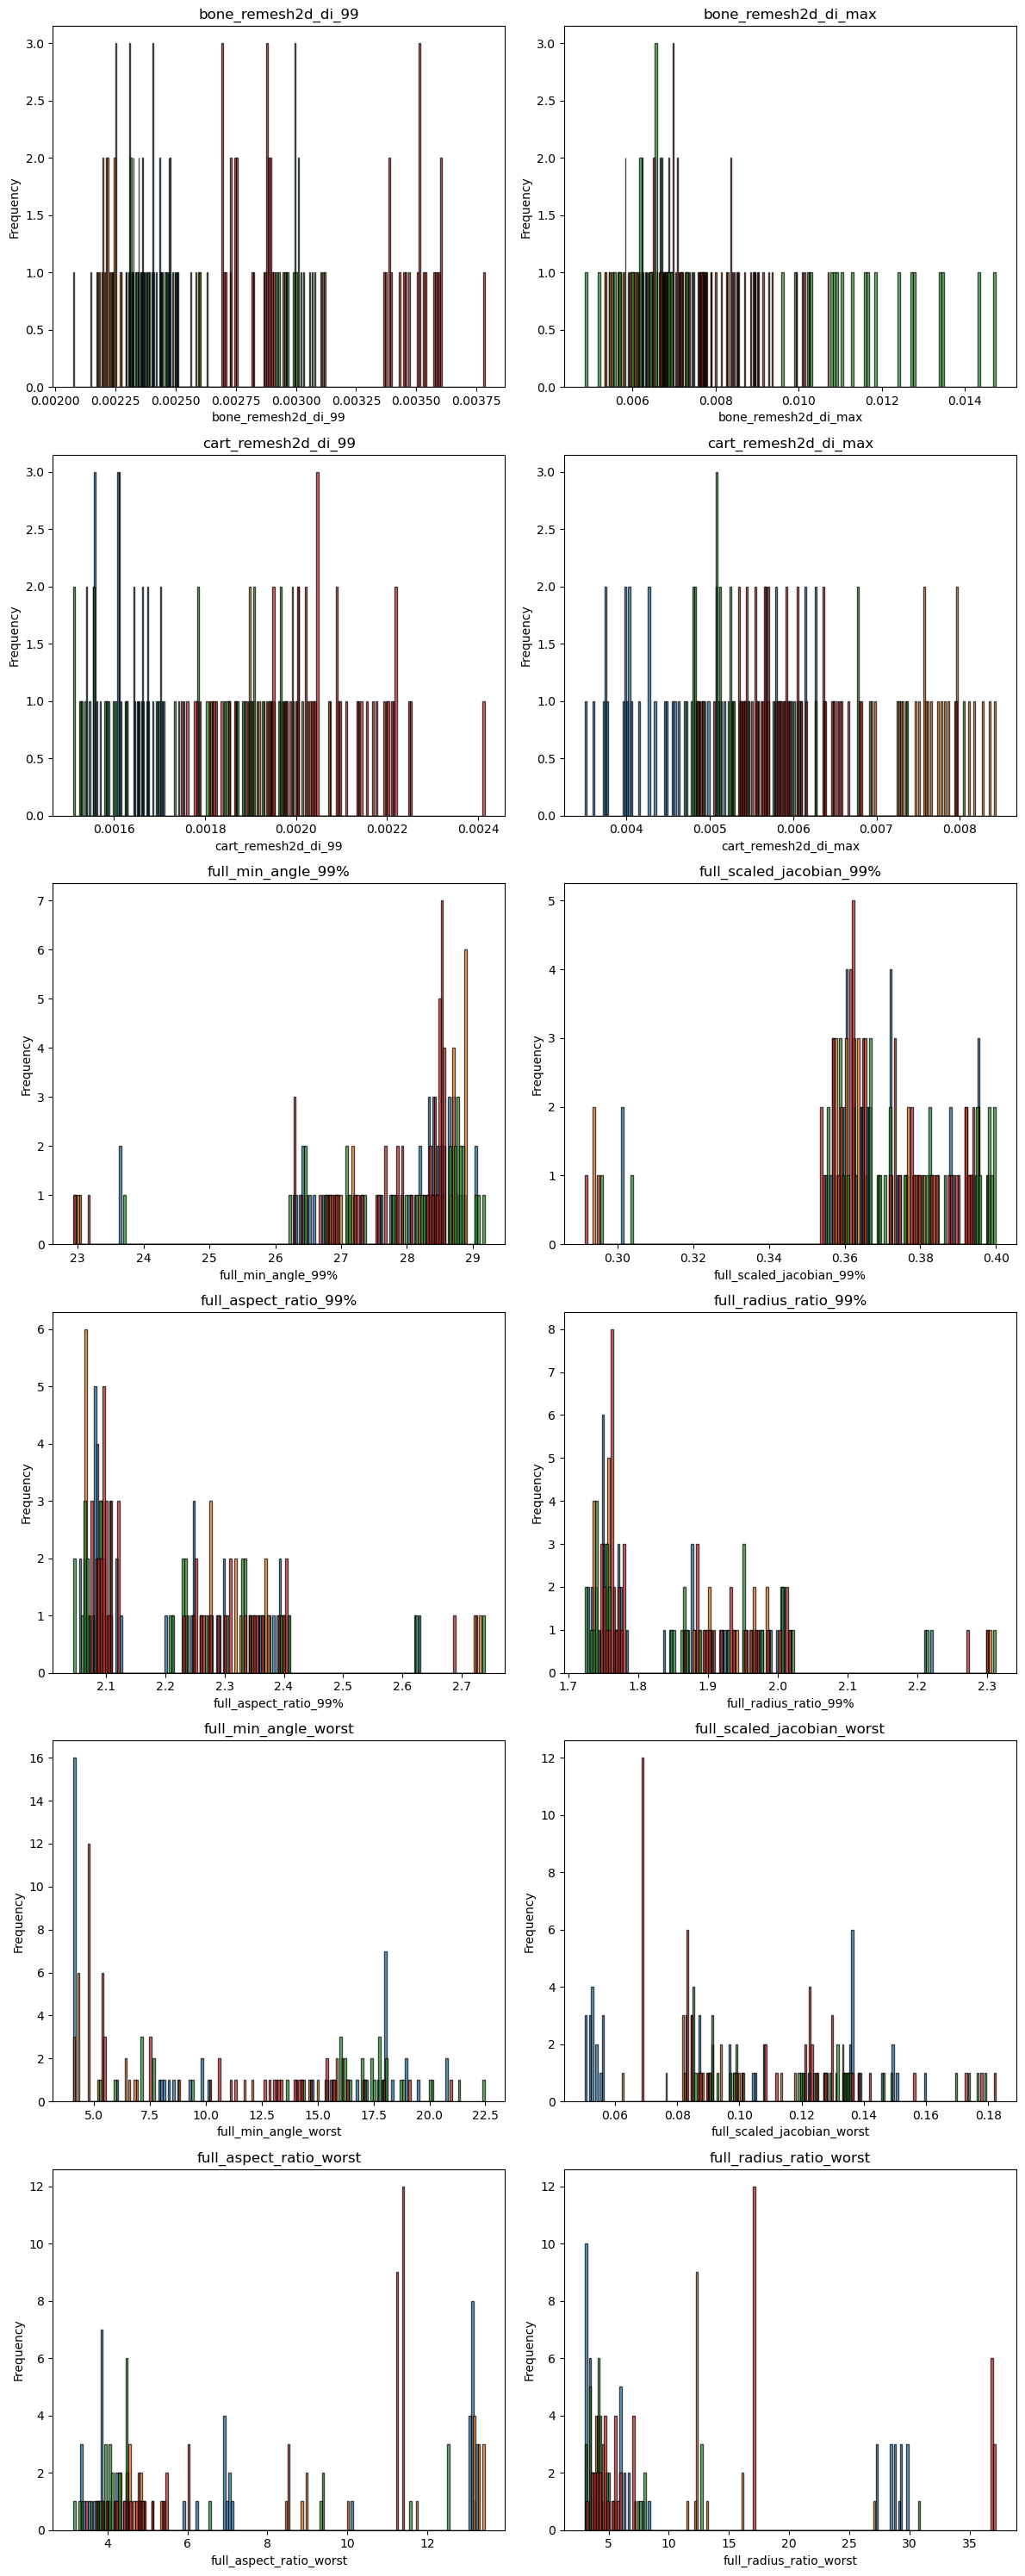

In [17]:
fig, ax = plt.subplots(6, 2, figsize=(12, 30))
ax = ax.flatten()

most_cells = qual.sort_values('full_n_cells').iloc[-1]
print(f'Highest element count:\n\t{most_cells['sub']} - {most_cells['full_n_cells']}')
for sub in df['sub'].unique():
    subject, side = sub[:-1], sub[-1]
    stl_path = get_subject_stl_path(subject, side)
    orig_bone = get_mesh(stl_path, 'tpm')
    L = avg_edge_length(orig_bone)
    #print(f"\n{sub}\n - Average edge length: {L:.4f} mm")
    #print(f' -   Max element count: {qual[qual['sub']==sub]['total_tets'].max()}')

    sub_df = df[df['sub']==sub]
    bins = int(len(df) / 1)
    for i, metric in enumerate(metrics):
        values = sub_df[metric]#[df_param['fd_bone']==0.8]
        # Histogram
        ax[i].hist(values, bins=bins, edgecolor='black', alpha=0.7, label=sub)
        ax[i].set_title(metric)
        ax[i].set_xlabel(metric)
        ax[i].set_ylabel('Frequency')

        #ax[i].legend()

plt.tight_layout()
plt.show()

In [18]:
q1_weight = 10
q2_weight = 25
q3_weight = 50

chosen_metrics = {

    f'{qual_part2}_min_angle_worst': {
        'ideal': 20,
        'acceptable': 15,
        'weight': q3_weight
    },

    f'{qual_part2}_scaled_jacobian_worst': {
        'ideal': 0.4,
        'acceptable': 0.3,
        'weight': q3_weight
    },

    f'{qual_part2}_aspect_ratio_worst': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q3_weight
    },

    f'{qual_part2}_radius_ratio_worst': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q3_weight
    },




    f'{qual_part}_min_angle_worst': {
        'ideal': 15,
        'acceptable': 10,
        'weight': q2_weight
    },

    f'{qual_part}_scaled_jacobian_worst': {
        'ideal': 0.3,
        'acceptable': 0.2,
        'weight': q2_weight
    },

    f'{qual_part}_aspect_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q2_weight
    },

    f'{qual_part}_radius_ratio_worst': {
        'ideal': 4,
        'acceptable': 5,
        'weight': q2_weight
    },

    f'{qual_part}_min_angle_99%': {
        'ideal': 30,
        'acceptable': 15,
        'weight': q1_weight
    },

    f'{qual_part}_scaled_jacobian_99%': {
        'ideal': 0.4,
        'acceptable': 0.3,
        'weight': q1_weight
    },

    f'{qual_part}_aspect_ratio_99%': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q1_weight
    },

    f'{qual_part}_radius_ratio_99%': {
        'ideal': 3,
        'acceptable': 4,
        'weight': q1_weight
    },
}

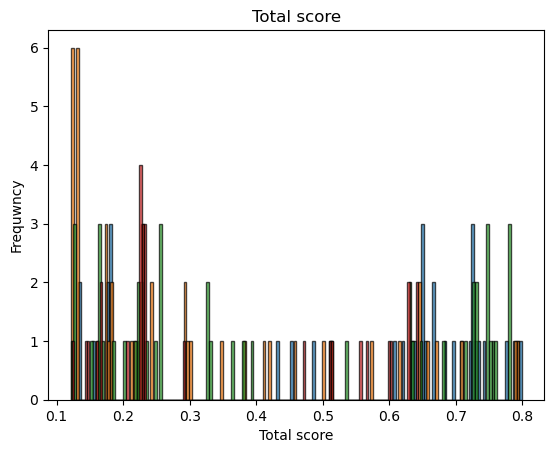

In [19]:
# Get scores

decay = 3
linear_floor = 0.5
total_weight = sum([w['weight'] for w in chosen_metrics.values()])

df_score = df[['sub', 'bone', 'run_id']].copy()
total = 0
for metric, bounds in chosen_metrics.items():
    score = score_value(df[metric], bounds['ideal'], bounds['acceptable'], linear_floor, decay)
    df_score[metric] = score
    total += score * bounds['weight'] / total_weight
df_score['total'] = total
df_score['rank_within_case'] = (
    df_score.groupby(['sub', 'bone'])['total']
    .rank(ascending=False, method='average')
)

# Merge with params

df_score = df_score.sort_values('total', ascending=False)

df_score_param = df_score.merge(
    df_param,
    on=['sub', 'bone', 'run_id'],
    how='left'
)
df_score_qual = df_qual.merge(
    df_score,
    on=['sub', 'bone', 'run_id'],
    how='left'
)

# Plot overall scores
fig, ax = plt.subplots()

subs = df_score['sub'].unique()
for sub in subs:
    sub_df = df_score[df_score['sub'] == sub]

    ax.hist(sub_df['total'], bins=round(len(df_score)/1), edgecolor='black', alpha=0.7, label=sub)

    ax.set_title("Total score")
    ax.set_xlabel('Total score')
    ax.set_ylabel('Frequwncy')
    #ax.legend()

In [20]:
# Best accross all subjects

df_grouped_rank = (
    df_score_param
    .groupby(df_param.columns[3:].to_list(), dropna=False)
    .agg(
        mean_rank=('rank_within_case', 'mean'),
        median_rank=('rank_within_case', 'median'),
        best_rank=('rank_within_case', 'min'),
        n_runs=('rank_within_case', 'size')
    )
    .reset_index()
    .sort_values('mean_rank')
)
df_grouped_rank.head(10)

,cgal_params.optimisation.odt,cgal_params.optimisation.lloyd,cgal_params.lloyd.max_iteration_number,cgal_params.lloyd.freeze_bound,cgal_params.odt.max_iteration_number,cgal_params.odt.freeze_bound,mean_rank,median_rank,best_rank,n_runs
8,False,True,20.0,0.0100,NaN,NaN,7.750000,5.5,4.0,4
10,False,True,30.0,0.0005,NaN,NaN,7.857143,6.0,4.0,7
7,False,True,20.0,0.0010,NaN,NaN,8.666667,7.0,2.0,6
21,True,False,NaN,NaN,30.0,0.0001,9.333333,7.5,3.0,6
5,False,True,20.0,0.0001,NaN,NaN,10.000000,11.0,2.0,5
6,False,True,20.0,0.0005,NaN,NaN,10.250000,7.5,3.0,4
12,False,True,30.0,0.0100,NaN,NaN,10.333333,8.5,3.0,6
1,False,True,10.0,0.0001,NaN,NaN,10.500000,10.0,1.0,8
20,True,False,NaN,NaN,20.0,0.0100,10.833333,12.0,3.0,6
2,False,True,10.0,0.0005,NaN,NaN,11.125000,11.5,1.0,8


In [21]:
best_per_tet = df_score_param.groupby(['sub', 'bone']).first()
best_per_tet

run_id  cart_inner_min_angle_worst  \
sub    bone                                          
14548R mc1    0-0-2-0f                    0.603111   
       tpm    0-0-0-0f                    1.000000   
50000R mc1    0-0-5-0b                    1.000000   
       tpm   0-0-11-0a                    1.000000   
50017L mc1    0-0-3-0d                    0.800454   
       tpm   0-0-12-0d                    0.084876   
50034R mc1    0-0-3-0d                    0.801896   
       tpm    0-0-3-0e                    1.000000   

             cart_inner_scaled_jacobian_worst  cart_inner_aspect_ratio_worst  \
sub    bone                                                                    
14548R mc1                           0.094717                       0.617482   
       tpm                           0.132586                       0.900160   
50000R mc1                           0.034926                       0.973113   
       tpm                           0.181612                       0.829738   
50017L mc1                           0.101622                       0.658930   
       tpm                           0.011131                       0.029710   
50034R mc1                           0.117005                       0.706003   
       tpm                           0.064737                       0.979685   

             cart_inner_radius_ratio_worst  full_min_angle_worst  \
sub    bone                                                        
14548R mc1                        0.853696              1.000000   
       tpm                        1.000000              1.000000   
50000R mc1                        1.000000              1.000000   
       tpm                        0.932380              1.000000   
50017L mc1                        0.927550              1.000000   
       tpm                        0.129489              0.702476   
50034R mc1                        1.000000              1.000000   
       tpm                        1.000000              1.000000   

             full_scaled_jacobian_worst  full_aspect_ratio_worst  \
sub    bone                                                        
14548R mc1                     0.295207                 1.000000   
       tpm                     0.221799                 1.000000   
50000R mc1                     0.113674                 1.000000   
       tpm                     0.150830                 1.000000   
50017L mc1                     0.016843                 0.663191   
       tpm                     0.063281                 0.165081   
50034R mc1                     0.052759                 0.942919   
       tpm                     0.250242                 1.000000   

             full_radius_ratio_worst  full_min_angle_99%  ...  \
sub    bone                                               ...   
14548R mc1                  0.966905            0.893568  ...   
       tpm                  1.000000            0.907048  ...   
50000R mc1                  1.000000            0.968980  ...   
       tpm                  1.000000            0.955198  ...   
50017L mc1                  0.569557            0.903575  ...   
       tpm                  0.104899            0.765939  ...   
50034R mc1                  0.884518            0.902549  ...   
       tpm                  1.000000            0.967560  ...   

             full_aspect_ratio_99%  full_radius_ratio_99%     total  \
sub    bone                                                           
14548R mc1                     1.0                    1.0  0.670043   
       tpm                     1.0                    1.0  0.795489   
50000R mc1                     1.0                    1.0  0.782823   
       tpm                     1.0                    1.0  0.780629   
50017L mc1                     1.0                    1.0  0.643396   
       tpm                     1.0                    1.0  0.207114   
50034R mc1                     1.0                    1.0  0.710044   
       tpm            

In [22]:
best_per_tet.merge(df_score_qual)[['sub', 'bone', 'run_id']+[x for x in df_score_qual.columns if '_x' in x]]

,sub,bone,run_id,full_min_angle_worst_x,full_min_angle_99%_x,full_radius_ratio_worst_x,full_radius_ratio_99%_x,full_aspect_ratio_worst_x,full_aspect_ratio_99%_x,full_scaled_jacobian_worst_x,full_scaled_jacobian_99%_x,cart_inner_min_angle_worst_x,cart_inner_radius_ratio_worst_x,cart_inner_aspect_ratio_worst_x,cart_inner_scaled_jacobian_worst_x
0,14548R,mc1,0-0-2-0f,15.370245,26.807028,4.066190,1.973467,3.894777,2.353345,0.182436,0.377519,16.031107,3.292608,3.765035,0.244543
1,14548R,tpm,0-0-0-0f,20.999484,27.211439,3.074538,1.935723,3.451242,2.308495,0.172905,0.384272,20.999484,2.889819,3.199679,0.255754
2,50000R,mc1,0-0-5-0b,20.797962,29.069414,3.055188,1.726623,3.321183,2.055119,0.150624,0.364521,21.013023,2.501515,3.053773,0.211287
3,50000R,tpm,0-0-11-0a,19.441088,28.655954,3.454731,1.837043,3.363079,2.201247,0.160052,0.398096,20.024427,3.135239,3.340524,0.266242
4,50017L,mc1,0-0-3-0d,17.106370,27.107258,4.860886,1.950493,4.673617,2.328980,0.086978,0.381029,18.004541,3.144900,3.682141,0.246888
5,50017L,tpm,0-0-12-0d,12.024761,22.978173,5.520535,2.305882,5.369391,2.732354,0.131099,0.293429,12.044301,4.450338,4.941042,0.173172
6,50034R,mc1,0-0-3-0d,17.521329,27.076483,4.230965,1.951166,4.114162,2.332767,0.125038,0.382788,18.018965,2.995461,3.587994,0.251587
7,50034R,tpm,0-0-3-0e,21.360940,29.026801,3.123056,1.733790,3.369256,2.060214,0.176927,0.368750,22.002361,2.594845,3.040631,0.231857
